# Project 2

#### 1994 U.S. Census Income Dataset retreived from the UCI library at the following link: https://archive.ics.uci.edu/ml/datasets/Census+Income 

References:
- https://www.youtube.com/watch?v=yyyYQVQF-yg
- https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html
- https://towardsdatascience.com/data-visualization-using-matplotlib-16f1aae5ce70 
- https://www.askpython.com/python-modules/python-seaborn-tutorial
- https://www.codegrepper.com/code-examples/whatever/compute+the+average+age+for+each+gender%3F+%2A
- https://blog.finxter.com/how-to-calculate-the-column-variance-of-a-dataframe-in-python-pandas/#:~:text=You%20can%20calculate%20the%20variance,interested%20in%20after%20the%20computation.
- https://www.shanelynn.ie/summarising-aggregation-and-grouping-data-in-python-pandas/
- https://www.geeksforgeeks.org/python-statistics-pvariance/?ref=gcse
- https://stackoverflow.com/questions/57842316/pandas-calculate-variance-from-aggregation
- https://www.statology.org/interpret-z-scores/
- https://datagy.io/python-z-score/
- https://www.geeksforgeeks.org/how-to-create-pie-chart-from-pandas-dataframe/

# Data Exploration

In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import scipy.stats as stats
import statistics as statss

#to access data set
url = 'https://drive.google.com/file/d/1SGjImJu_wngJ7rLZA57QrGax31nTcJxh/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id=1SGjImJu_wngJ7rLZA57QrGax31nTcJxh'

#renaming columns to make it more concise/understandable
headerColumns = ['Age', 'Workclass', 'Final Weight', 'Education', 'Educational-Number', 'Marital Status', 'Occupation', 
          'Familial Relationship', 'Race', 'Sex', 'Capital Gain ($)', 'Capital Loss ($)', 'Hours Worked Per Week', 'Native Country', 'Annual Salary ($)']
df = pd.read_csv(path, header= None, skiprows= 0, names= headerColumns)

df.head(28)

,Age,Workclass,Final Weight,Education,Educational-Number,Marital Status,Occupation,Familial Relationship,Race,Sex,Capital Gain ($),Capital Loss ($),Hours Worked Per Week,Native Country,Annual Salary ($)
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [2]:
#question mark symbols are classified as an object data type in Workclass, Occupation, and Native Country
#shows no null values in the columns
df.info()

#showing the mean,max,min, statistical data from numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    32561 non-null  int64 
 1   Workclass              32561 non-null  object
 2   Final Weight           32561 non-null  int64 
 3   Education              32561 non-null  object
 4   Educational-Number     32561 non-null  int64 
 5   Marital Status         32561 non-null  object
 6   Occupation             32561 non-null  object
 7   Familial Relationship  32561 non-null  object
 8   Race                   32561 non-null  object
 9   Sex                    32561 non-null  object
 10  Capital Gain ($)       32561 non-null  int64 
 11  Capital Loss ($)       32561 non-null  int64 
 12  Hours Worked Per Week  32561 non-null  int64 
 13  Native Country         32561 non-null  object
 14  Annual Salary ($)      32561 non-null  object
dtypes: int64(6), object

,Age,Final Weight,Educational-Number,Capital Gain ($),Capital Loss ($),Hours Worked Per Week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [3]:
#check unique values, question marks found in columns Workclass, Occupation, and Native County
for col in df.columns:
    print('{}: {}'.format(col,df[col].unique()))

Age: [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
Workclass: [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
Final Weight: [ 77516  83311 215646 ...  34066  84661 257302]
Education: [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
Educational-Number: [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
Marital Status: [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
Occupation: [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fi

####  Showing how many times the question marks (?) appear in certain columns

In [4]:
df['Workclass'].value_counts()

 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
 ?                    1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: Workclass, dtype: int64

In [5]:
df['Occupation'].value_counts()

 Prof-specialty       4140
 Craft-repair         4099
 Exec-managerial      4066
 Adm-clerical         3770
 Sales                3650
 Other-service        3295
 Machine-op-inspct    2002
 ?                    1843
 Transport-moving     1597
 Handlers-cleaners    1370
 Farming-fishing       994
 Tech-support          928
 Protective-serv       649
 Priv-house-serv       149
 Armed-Forces            9
Name: Occupation, dtype: int64

# Data Cleaning: Condensing/Renaming Data
- A lot of data needs to get further condensed into categories for users to understand; a lot of redundant or poor naming. 
- Many countries had to be renamed due to improper spelling or categorized due to current names of those countries. - Many columns had renaming to make it more understandable, visually appealing, and simple for viewers
- In Project 1, Married-civ-spouse, Married-spouse-absent, and Married-AF-spouse were condensed to be named Married. However, this isn't realistic since censuses specify and include if spouse absent, etc.
- For Project 2, no more condensing is used in those categories mentioned. Instead, those names are kept the same as they were.

In [6]:
#removing question marks from data
#all question mark symbols are now gone
df['Workclass'] = df['Workclass'].str.replace('?', 'No Documentation/Unknown', regex=True)
df['Occupation'] = df['Occupation'].str.replace('?', 'No Documentation/Unknown', regex=True)
df['Native Country'] = df['Native Country'].str.replace('?', 'No Documentation/Unknown', regex=True)

#renaming/making education column more concise
df.Education =  df.Education.replace(['Preschool', '1st-4th', '5th-6th','7th-8th','9th', '10th', '11th', '12th'], 'K-12, no HS Diploma', regex=True)
df.Education =  df.Education.replace(['HS-grad'], 'High School Diploma', regex=True)
df.Education =  df.Education.replace(['Some-college','Prof-school'], 'Other', regex=True)
df.Education = df.Education.replace(['Assoc-voc','Assoc-acdm'], 'Associate Degree', regex=True)
df.Education =  df.Education.replace(['Bachelors'], 'Undergraduate Degree', regex=True)
df.Education =  df.Education.replace(['Masters', 'Doctorate'], 'Graduate Degree', regex=True)

#renaming/making workclass column more concise
df.Workclass =  df.Workclass.replace(['Self-emp-not-inc','Self-emp-inc'], 'Self Employed', regex=True)
df.Workclass =  df.Workclass.replace(['State-gov', 'Local-gov'], 'State Government', regex=True)
df.Workclass =  df.Workclass.replace(['Federal-gov'], 'Federal Government', regex=True)
df.Workclass =  df.Workclass.replace(['Private'], 'Private Sector', regex=True)
df.Workclass =  df.Workclass.replace(['Without-pay'], 'Unpaid', regex=True)
df.Workclass =  df.Workclass.replace(['Never-worked'], 'Unemployed', regex=True)

#renaming/making marital status column more concise
df['Marital Status'] =  df['Marital Status'].replace(['Never-married'], 'Not Married', regex=True)

#renaming/making familial relationship column more concise
df['Familial Relationship'] =  df['Familial Relationship'].replace(['Unmarried','Other-relative'], 'Other Relative', regex=True)
df['Familial Relationship'] =  df['Familial Relationship'].replace(['Own-child'], 'Child', regex=True)
df['Familial Relationship'] =  df['Familial Relationship'].replace(['Not-in-family'], 'No Familial Relation', regex=True)

#renaming/making marital status column more concise
#Trinidad and Tobago was mispelled, Yugoslavia is now historically inaccurate
#Netherlands is the current name instead of Holland, Scotland isn't country so I put under United Kingdom
df['Native Country'] =  df['Native Country'].replace(['South'], 'South Korea', regex=True)
df['Native Country'] =  df['Native Country'].replace(['Holand-Netherlands'], 'The Netherlands', regex=True)
df['Native Country'] =  df['Native Country'].replace(['Yugoslavia'], 'Former Socialist Republic of Yugoslavia', regex=True)
df['Native Country'] =  df['Native Country'].replace(['Trinadad&Tobago'], 'Trinidad and Tobago', regex=True)
df['Native Country'] =  df['Native Country'].replace(['England', 'Scotland'], 'United Kingdom', regex=True)

In [7]:
#proof question marks gone and code works
df['Workclass'].value_counts()

 Private Sector              22696
 Self Employed                3657
 State Government             3391
 No Documentation/Unknown     1836
 Federal Government            960
 Unpaid                         14
 Unemployed                      7
Name: Workclass, dtype: int64

In [8]:
#proof code works
df['Native Country'].value_counts()

 United-States                              29170
 Mexico                                       643
 No Documentation/Unknown                     583
 Philippines                                  198
 Germany                                      137
 Canada                                       121
 Puerto-Rico                                  114
 El-Salvador                                  106
 United Kingdom                               102
 India                                        100
 Cuba                                          95
 Jamaica                                       81
 South Korea                                   80
 China                                         75
 Italy                                         73
 Dominican-Republic                            70
 Vietnam                                       67
 Guatemala                                     64
 Japan                                         62
 Poland                                        60


In [9]:
#updated changes are evident
df.head(28)

,Age,Workclass,Final Weight,Education,Educational-Number,Marital Status,Occupation,Familial Relationship,Race,Sex,Capital Gain ($),Capital Loss ($),Hours Worked Per Week,Native Country,Annual Salary ($)
0,39,State Government,77516,Undergraduate Degree,13,Not Married,Adm-clerical,No Familial Relation,White,Male,2174,0,40,United-States,<=50K
1,50,Self Employed,83311,Undergraduate Degree,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private Sector,215646,High School Diploma,9,Divorced,Handlers-cleaners,No Familial Relation,White,Male,0,0,40,United-States,<=50K
3,53,Private Sector,234721,"K-12, no HS Diploma",7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private Sector,338409,Undergraduate Degree,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private Sector,284582,Graduate Degree,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private Sector,160187,"K-12, no HS Diploma",5,Married-spouse-absent,Other-service,No Familial Relation,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self Employed,209642,High School Diploma,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private Sector,45781,Graduate Degree,14,Not Married,Prof-specialty,No Familial Relation,White,Female,14084,0,50,United-States,>50K
9,42,Private Sector,159449,Undergraduate Degree,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


## Sample EDA Visualizations 

In [10]:
df.corr()

,Age,Final Weight,Educational-Number,Capital Gain ($),Capital Loss ($),Hours Worked Per Week
Age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
Final Weight,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
Educational-Number,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
Capital Gain ($),0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
Capital Loss ($),0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
Hours Worked Per Week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


<AxesSubplot:>

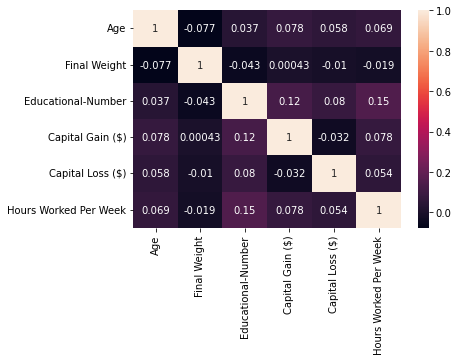

In [11]:
#overall not a strong correlation; lots of negative numbers
sb.heatmap(df.corr(), annot = True)

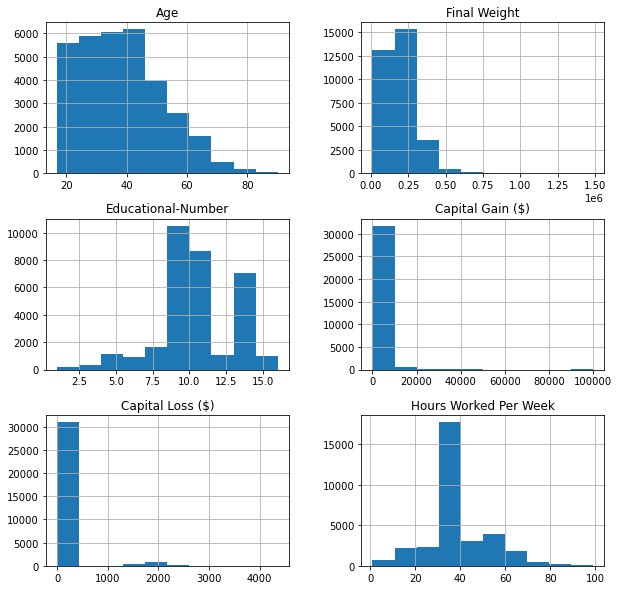

In [12]:
df.hist(bins=10, figsize=(10, 10))
plt.show()

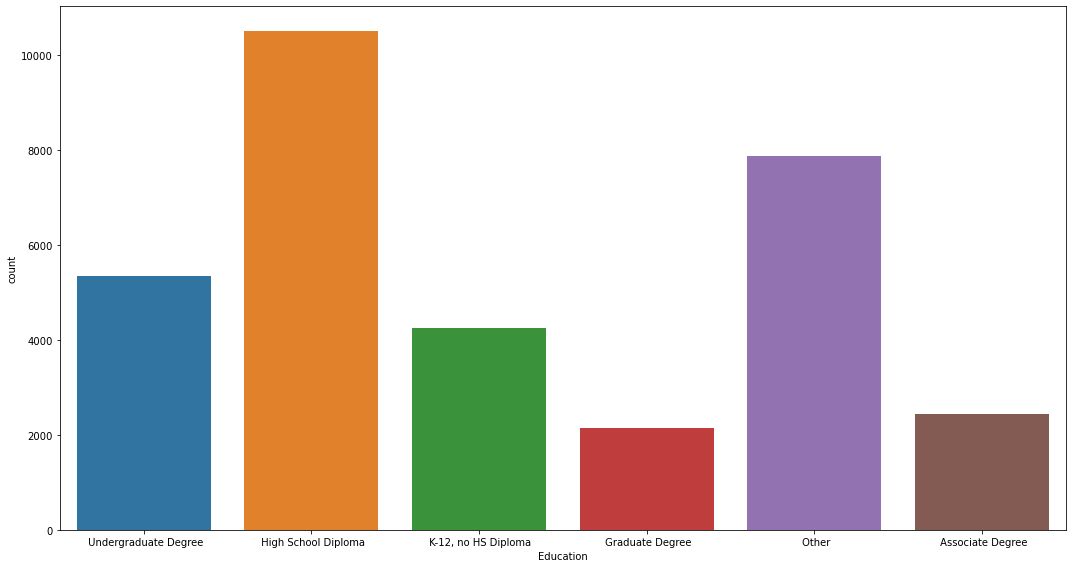

In [13]:
#the most common education received in 1994 was High School/a High School Diploma
educationFig = plt.figure(figsize=(15,8))
sb.countplot('Education', data= df)
plt.tight_layout()
plt.show()

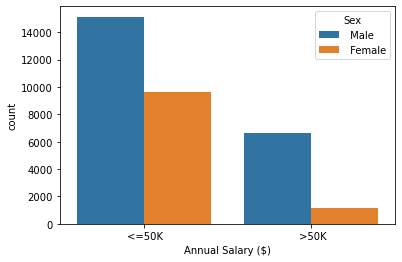

In [14]:
#based off data set, men have a higher income than women
sb.countplot(df['Annual Salary ($)'], hue = 'Sex', data = df);

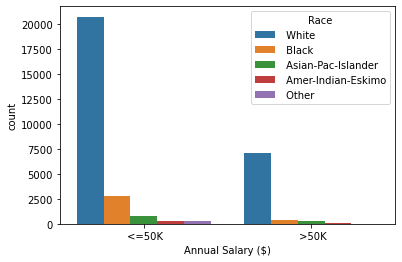

In [15]:
#based off data set, white people have the highest income out of all the races 
sb.countplot(df['Annual Salary ($)'], hue = 'Race', data = df);

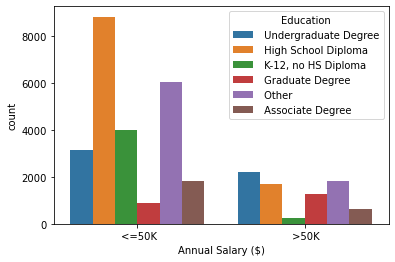

In [16]:
#out of all the people, those with an undergraduate degree have the highest income/make >50K
#shockingly, those with an undergraduate degree have a higher income overall than those with a graduate degree
#alarming to see a large amount of people with graduate degrees earning an income of <50K a year
sb.countplot(df['Annual Salary ($)'], hue = 'Education', data = df);

# Hypotheses

## 1.) Does the average age of men vary compared to average age of women? 
- Hypothesized that the average age of males is greater than the average age of females; 45 was predicted mean age overall
- The alternative hypothesis is that the average of females is greater than or equal to the average age of males. 
- The populations and variance of age will be analyzed

In [17]:
#printing average age out of whole dataset
#The hypothesis of the average overall age being 45 is rejected
df.mean()
print(df.loc[:,'Age'].mean())

38.58164675532078


In [18]:
#showing count/population of males and females
#showing separately average ages for males and females
#out of 10,771 women, the average female age in the dataset is 36
#out of 21,790 men, the average male age in the dataset is 39
#this shows the hypothesis is confirmed; the average age of men is greater than female
df.groupby('Sex').Age.describe()

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female,10771.0,36.858230,14.013697,17.0,25.0,35.0,46.0,90.0
Male,21790.0,39.433547,13.370630,17.0,29.0,38.0,48.0,90.0


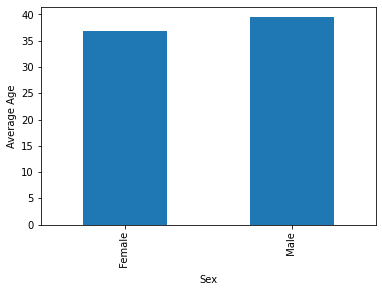

In [19]:
#plotting the average ages for both men and women respectively
df.groupby('Sex').Age.mean().plot(kind = 'bar')
plt.ylabel('Average Age')
plt.show()

Variance is a measure of how data points differ from the mean.
It measures how far the data is spread out from their mean value. Variance aims to find the expected difference of deviation from actual value.

Pvariance was used instead of variance since pvariance measures the entire population whereas variance is just a sample

The model isn't presenting an accurate depiction of the relationship. This causes errors. This doesn't show a representative difference between the model's predicted value and actual value

In [20]:
#High variance. Population data points are spread out from the mean and from one another
#Variance < 10 is good, this isn't ideal because the pvariance > 10
print('Population variance is %s' %(statss.pvariance(df.Age)))

Population variance is 186.05568600783081


In [21]:
#checking age variance for males and females
#High difference between variance and mean. Data points too spread out from mean when considering one's gender/age 
df.groupby('Sex').Age.agg(['mean','var']).reset_index()

,Sex,mean,var
0,Female,36.858230,196.383706
1,Male,39.433547,178.773752


### Yes, the average age of men varies compared to the average age of women. The hypothesis has been rejected in regards to the predicted mean age of the whole dataset. But, the hypothesis was correct in regards to a high variance or large spread for age and gender. 
Strictly analyzing the high variance number, this isn't ideal, but the hypothesis was right in terms of variability

## 2.) Which gender works more hours per week?
- Hypothesized that men work more hours per week than women
- The alternative hypothesis is that women work more or an equal amount of hours worked per week compared to men

In [22]:
#the mean and count for men are higher regarding number of hours worked per week
#hypothesis is accepted; men do work more hours per week on average and overall compared to women
df.groupby(['Sex'])['Hours Worked Per Week'].describe().reset_index()

,Sex,count,mean,std,min,25%,50%,75%,max
0,Female,10771.0,36.410361,11.811300,1.0,30.0,40.0,40.0,99.0
1,Male,21790.0,42.428086,12.119755,1.0,40.0,40.0,49.0,99.0


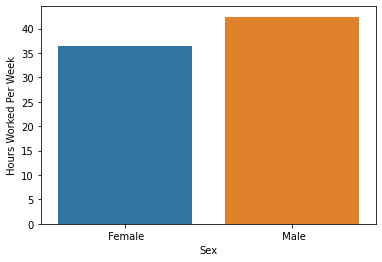

In [23]:
#on average, men work more hours per week than women
hypoth2 = df.groupby(['Sex'])['Hours Worked Per Week'].mean().reset_index()
ax = sb.barplot(x='Sex', y='Hours Worked Per Week', data= hypoth2)

<AxesSubplot:ylabel='Hours Worked Per Week'>

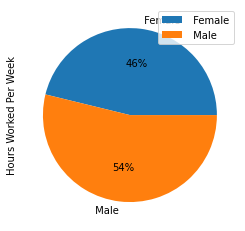

In [24]:
#depicting same thing as above just in pie chart form showing percentages 
#on average, men work more hours per week than women
#on average, men work 54% more hours per week than women
df.groupby(['Sex']).mean().plot(kind='pie', y ='Hours Worked Per Week', autopct='%1.0f%%')

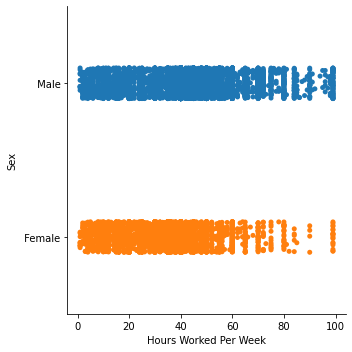

In [25]:
#catplot() measures between numerical and categorical data
#based on this visualization, more men work 80-100 hours per week than women do
#men work more than women do
sb.catplot(x= 'Hours Worked Per Week', y = 'Sex', data= df)
plt.show()

### Hypothesis is accepted; men work more hours per week than women. Women do not work more or an equal amount of hours than men. 

## Extra Material-Is there any difference between the mean age for men and women given that we know the average and standard deviation of the age for both genders? (not part of hypotheses)
 
When df.describe() was executed, the mean and standard deviation was shown

A Z-Test is performed to compare the average of the sample mean against the population mean. I can perform a Z-Test since this applies to a large sample size and the population std deviation is known.

#### The value of the z-score tells you how many standard deviations you are away from the mean. This shows a sample of the first 5 people.

In [26]:
#z-scores for first 5 people
df['Age zscore'] = stats.zscore(df['Age'])
print(df.head(5))

   Age          Workclass  Final Weight              Education  \
0   39   State Government         77516   Undergraduate Degree   
1   50      Self Employed         83311   Undergraduate Degree   
2   38     Private Sector        215646    High School Diploma   
3   53     Private Sector        234721    K-12, no HS Diploma   
4   28     Private Sector        338409   Undergraduate Degree   

   Educational-Number       Marital Status          Occupation  \
0                  13          Not Married        Adm-clerical   
1                  13   Married-civ-spouse     Exec-managerial   
2                   9             Divorced   Handlers-cleaners   
3                   7   Married-civ-spouse   Handlers-cleaners   
4                  13   Married-civ-spouse      Prof-specialty   

   Familial Relationship    Race      Sex  Capital Gain ($)  Capital Loss ($)  \
0   No Familial Relation   White     Male              2174                 0   
1                Husband   White     Male   

### Person 0 and 1
- Positive values. Individual value > mean.
- If z-score = 0, individual value is equal to the mean. None are equal, but person 0 and 1 are close to mean

### Person 2 and 4
 - Negative Values. Individual value < mean
 
### Person 3
- Z-score > 1, Positive value. Individual value > mean and value is roughly 1.06 std deviations away from mean

### Yes, there is a difference in mean for men and women. This was another way to see the difference in mean,